# Step 3: Cessi's model and its landscape

Does Cessi's (1994) one-equation model show the same two states and the same hysteresis as Stommel's model, and can I picture it as a ball rolling in a landscape? Here I draw its equilibria, fold points and potential, and ramp the freshwater forcing up and down.

I load the libraries and the Cessi functions from `src/models.py`. `%matplotlib inline` makes the figures show inside the notebook. The two `sys.path` lines let Python find `models.py`, which sits in the `src/` folder.

In [1]:
%matplotlib inline

import os

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")   # models.py lives in the project's src/ folder

from models import (cessi_p_of_y, cessi_dpdy, cessi_potential,
                    cessi_equilibria, cessi_fold_points, cessi_run_ramp)

These are the parameter values: mu^2, the forcing values for the landscape plot, and the ramp settings.

In [2]:
# ---------------- parameters ----------------
MU2 = 6.2                 # Cessi's mu^2 = t_d / t_a: diffusion time over advection time
DIFFUSION_TIME_YR = 219   # one model time unit in years

Y_MIN = -0.2              # y range for the equilibrium diagram and the potential
Y_MAX = 1.6
N_Y = 2001                # points along y

P_LANDSCAPE = [1.0, 1.1, 1.2, 1.35]   # forcing values for the potential plot
P_BARRIER = 1.1                       # forcing at which valleys, hill and barriers are printed

P_LOW = 0.8               # start and end of the forcing ramp
P_HIGH = 1.5              # top of the forcing ramp
RAMP_TIME = 500.0         # time for each direction of the ramp (diffusion times); slow compared with relaxation time ~0.5
SLOW_FACTOR = 4           # extra run with a ramp this many times slower, to see if the jump moves closer to the fold
DT = 0.01                 # Euler time step (diffusion times)

FIG_DIR = "../figures"
# --------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

I draw the equilibrium curve sideways: I pick y and compute p, which is one formula instead of solving a cubic. The slope dp/dy tells me which parts are stable. The fold points come from the quadratic formula.

In [3]:
# ---- 1. Equilibrium diagram: p as a function of y ----
# Solving for p given y is easy (one formula). Solving for y given p means
# solving a cubic. So we draw the curve "sideways": pick y, compute p.
y_grid = np.linspace(Y_MIN, Y_MAX, N_Y)
p_curve = cessi_p_of_y(y_grid, MU2)
slope = cessi_dpdy(y_grid, MU2)

# Split into stable (dp/dy > 0) and unstable (dp/dy < 0) parts with NaN gaps
y_stable = np.where(slope > 0, y_grid, np.nan)
y_unstable = np.where(slope <= 0, y_grid, np.nan)

y_fold_low, p_fold_low, y_fold_high, p_fold_high = cessi_fold_points(MU2)
# y_fold_low (smaller y) is where the strong branch ends, at the larger p.
# y_fold_high (larger y) is where the weak branch ends, at the smaller p.

At p = 1.1 I find the two valleys and the hill with `np.roots`, and compute the barrier height from each valley to the hill. Step 4 needs these numbers.

In [4]:
# ---- 2. Potential at p = P_BARRIER: valleys, hill and barrier heights ----
eq = cessi_equilibria(P_BARRIER, MU2)
if len(eq) != 3:
    raise RuntimeError(f"expected 3 equilibria at p = {P_BARRIER}, found {len(eq)}")
y_strong, y_hill, y_weak = eq      # sorted: small y (strong flow), hill, large y (weak flow)
V_strong = cessi_potential(y_strong, P_BARRIER, MU2)
V_hill = cessi_potential(y_hill, P_BARRIER, MU2)
V_weak = cessi_potential(y_weak, P_BARRIER, MU2)
barrier_from_strong = V_hill - V_strong
barrier_from_weak = V_hill - V_weak

This function ramps p from 0.8 to 1.5 and back with forward Euler, starting on the strong branch. p changes a little at every step, so y is always moving.

In [5]:
# ---- 3. Hysteresis: ramp p slowly up and back down ----
# p changes a tiny bit every time step, so the system is never quite at rest.
# Because the ramp is slow, y follows the stable branch it is on until that
# branch ends at a fold.
def run_up_and_down(dt, ramp_time):
    n_steps = int(round(ramp_time / dt))
    p_up = np.linspace(P_LOW, P_HIGH, n_steps + 1)
    p_down = np.linspace(P_HIGH, P_LOW, n_steps + 1)
    y_start = cessi_equilibria(P_LOW, MU2)[0]      # start on the strong branch
    y_up = cessi_run_ramp(y_start, p_up, MU2, dt)
    y_down = cessi_run_ramp(y_up[-1], p_down, MU2, dt)
    return p_up, y_up, p_down, y_down

This function finds where y changes fastest, which marks the jump between branches.

In [6]:
def jump_location(p_values, y_values):
    """p where y changes fastest, which marks the jump between branches."""
    steps = np.abs(np.diff(y_values))
    i = np.argmax(steps)
    return p_values[i]

Here I run the ramp and locate the jump in each direction.

In [7]:
p_up, y_up, p_down, y_down = run_up_and_down(DT, RAMP_TIME)
p_jump_up = jump_location(p_up, y_up)
p_jump_down = jump_location(p_down, y_down)

I repeat the ramp with dt/2. y is always moving here, so this tests a real transient, not just an end state.

In [8]:
# Same ramp with dt/2. Here y is always moving, so unlike the end-state
# checks in steps 1 and 2 this compares a real transient.
p_up_h, y_up_h, p_down_h, y_down_h = run_up_and_down(DT / 2, RAMP_TIME)
dt_diff = max(np.max(np.abs(y_up - y_up_h[::2])), np.max(np.abs(y_down - y_down_h[::2])))
p_jump_up_h = jump_location(p_up_h, y_up_h)
p_jump_down_h = jump_location(p_down_h, y_down_h)

I repeat the ramp 4 times more slowly to see whether the jumps move closer to the folds. They should, if the overshoot is a delay caused by the finite ramp speed.

In [9]:
# A slower ramp. Near a fold the pull toward equilibrium is very weak, so y
# needs time to leave. If the overshoot past the fold comes from this
# delay, a slower ramp should give a smaller overshoot.
p_up_s, y_up_s, p_down_s, y_down_s = run_up_and_down(DT, SLOW_FACTOR * RAMP_TIME)
p_jump_up_s = jump_location(p_up_s, y_up_s)
p_jump_down_s = jump_location(p_down_s, y_down_s)

This figure shows the equilibrium diagram, the S-shaped curve with its two folds.

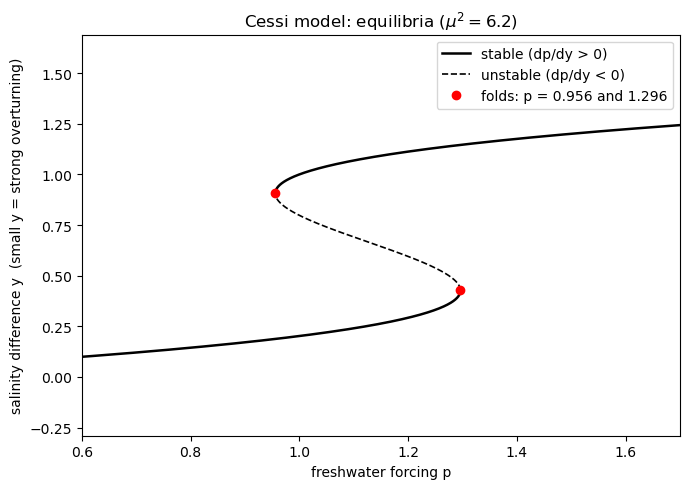

In [10]:
# ---- 4. Figure 1: equilibrium diagram ----
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(p_curve, y_stable, "k-", lw=1.8, label="stable (dp/dy > 0)")
ax.plot(p_curve, y_unstable, "k--", lw=1.2, label="unstable (dp/dy < 0)")
ax.plot([p_fold_low, p_fold_high], [y_fold_low, y_fold_high], "ro",
        label=f"folds: p = {p_fold_high:.3f} and {p_fold_low:.3f}")
ax.set_xlim(0.6, 1.7)
ax.set_xlabel("freshwater forcing p")
ax.set_ylabel("salinity difference y  (small y = strong overturning)")
ax.set_title(r"Cessi model: equilibria ($\mu^2 = 6.2$)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_cessi_equilibria.png"), dpi=150)
plt.show()

This figure shows the potential V(y) for four forcing values, with the valleys and hill at p = 1.1 marked.

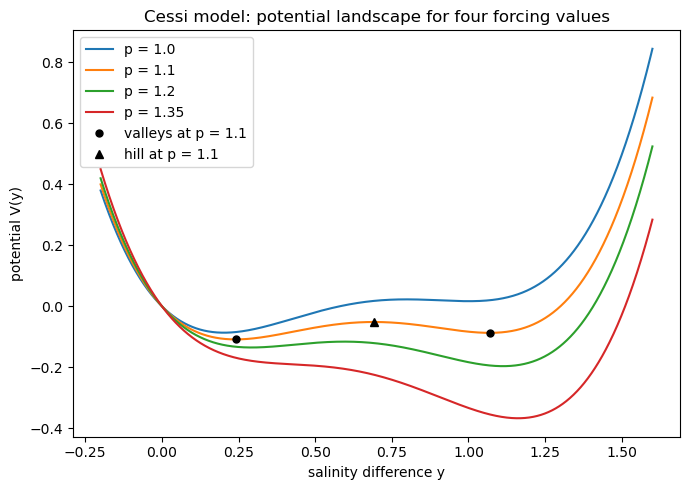

In [11]:
# ---- 5. Figure 2: potential landscapes ----
fig, ax = plt.subplots(figsize=(7, 5))
for p in P_LANDSCAPE:
    ax.plot(y_grid, cessi_potential(y_grid, p, MU2), label=f"p = {p}")
ax.plot([y_strong, y_weak], [V_strong, V_weak], "ko", ms=5, label=f"valleys at p = {P_BARRIER}")
ax.plot([y_hill], [V_hill], "k^", ms=6, label=f"hill at p = {P_BARRIER}")
ax.set_xlabel("salinity difference y")
ax.set_ylabel("potential V(y)")
ax.set_title("Cessi model: potential landscape for four forcing values")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_cessi_potential.png"), dpi=150)
plt.show()

This figure shows the up and down ramps on top of the equilibria, with the folds as dotted lines.

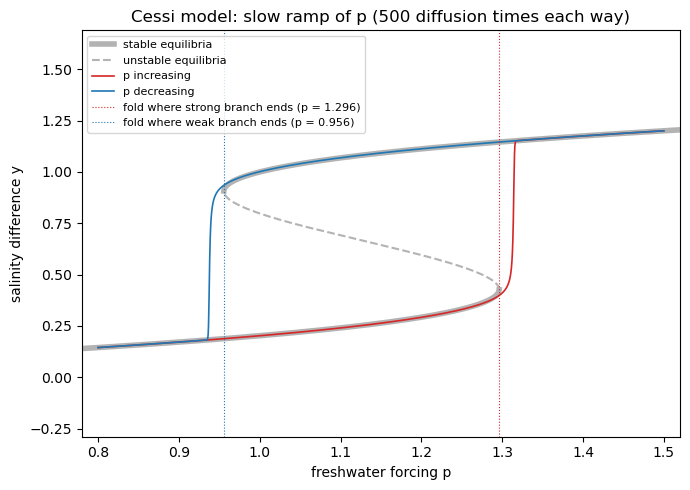

In [12]:
# ---- 6. Figure 3: hysteresis ----
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(p_curve, y_stable, color="0.7", lw=4, label="stable equilibria")
ax.plot(p_curve, y_unstable, color="0.7", lw=1.5, ls="--", label="unstable equilibria")
ax.plot(p_up, y_up, color="tab:red", lw=1.2, label="p increasing")
ax.plot(p_down, y_down, color="tab:blue", lw=1.2, label="p decreasing")
ax.axvline(p_fold_low, color="tab:red", ls=":", lw=0.8, label=f"fold where strong branch ends (p = {p_fold_low:.3f})")
ax.axvline(p_fold_high, color="tab:blue", ls=":", lw=0.8, label=f"fold where weak branch ends (p = {p_fold_high:.3f})")
ax.set_xlim(P_LOW - 0.02, P_HIGH + 0.02)
ax.set_xlabel("freshwater forcing p")
ax.set_ylabel("salinity difference y")
ax.set_title(f"Cessi model: slow ramp of p ({RAMP_TIME:.0f} diffusion times each way)")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_cessi_hysteresis.png"), dpi=150)
plt.show()

Finally I print the fold points, the landscape at p = 1.1, the jump locations for both ramp speeds, and the time step check.

In [13]:
# ---- 7. Print the key numbers ----
print(f"Fold points (mu2 = {MU2}):")
print(f"  strong branch ends at y = {y_fold_low:.4f}, p = {p_fold_low:.4f}   (Cessi 1994, Fig. 4: about 1.3)")
print(f"  weak branch ends at   y = {y_fold_high:.4f}, p = {p_fold_high:.4f}   (no published value found)")
print()
print(f"Landscape at p = {P_BARRIER}:")
print(f"  strong valley y = {y_strong:.4f}   (Yang et al. 2021: 0.2402), V = {V_strong:.5f}")
print(f"  hill          y = {y_hill:.4f}   (Yang et al. 2021: 0.6911), V = {V_hill:.5f}")
print(f"  weak valley   y = {y_weak:.4f}   (Yang et al. 2021: 1.0687), V = {V_weak:.5f}")
print(f"  barrier from strong valley to hill: {barrier_from_strong:.5f}")
print(f"  barrier from weak valley to hill:   {barrier_from_weak:.5f}")
print()
print(f"Ramp: {RAMP_TIME:.0f} diffusion times each way = {RAMP_TIME * DIFFUSION_TIME_YR:,.0f} years")
print(f"  jump on the way up at   p = {p_jump_up:.4f}  (fold at {p_fold_low:.4f}, overshoot {p_jump_up - p_fold_low:+.4f})")
print(f"  jump on the way down at p = {p_jump_down:.4f}  (fold at {p_fold_high:.4f}, overshoot {p_jump_down - p_fold_high:+.4f})")
print(f"Ramp {SLOW_FACTOR} times slower:")
print(f"  jump on the way up at   p = {p_jump_up_s:.4f}  (overshoot {p_jump_up_s - p_fold_low:+.4f})")
print(f"  jump on the way down at p = {p_jump_down_s:.4f}  (overshoot {p_jump_down_s - p_fold_high:+.4f})")
print(f"dt check: largest difference in y along the ramp, dt = {DT} vs {DT / 2}: {dt_diff:.2e}")
print(f"          jump locations with dt/2: up {p_jump_up_h:.4f}, down {p_jump_down_h:.4f}")

Fold points (mu2 = 6.2):
  strong branch ends at y = 0.4272, p = 1.2962   (Cessi 1994, Fig. 4: about 1.3)
  weak branch ends at   y = 0.9061, p = 0.9556   (no published value found)

Landscape at p = 1.1:
  strong valley y = 0.2402   (Yang et al. 2021: 0.2402), V = -0.10864
  hill          y = 0.6911   (Yang et al. 2021: 0.6911), V = -0.05154
  weak valley   y = 1.0687   (Yang et al. 2021: 1.0687), V = -0.08714
  barrier from strong valley to hill: 0.05710
  barrier from weak valley to hill:   0.03560

Ramp: 500 diffusion times each way = 109,500 years
  jump on the way up at   p = 1.3144  (fold at 1.2962, overshoot +0.0182)
  jump on the way down at p = 0.9375  (fold at 0.9556, overshoot -0.0182)
Ramp 4 times slower:
  jump on the way up at   p = 1.3034  (overshoot +0.0072)
  jump on the way down at p = 0.9484  (overshoot -0.0072)
dt check: largest difference in y along the ramp, dt = 0.01 vs 0.005: 3.42e-03
          jump locations with dt/2: up 1.3144, down 0.9375
